In [3]:

import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [17]:
X_train_flatten = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
X_test_flatten = X_test.reshape(X_test.shape[0], -1).astype(np.float32)
X_train_flatten /=255
X_test_flatten /=255

print(X_train_flatten.shape)
print(y_train[:10])

(60000, 784)
[5 0 4 1 9 2 1 3 1 4]


In [25]:
base_model = LogisticRegression( solver='lbfgs', max_iter=500, random_state=42)
base_model.fit(X_train_flatten, y_train)
base_acc = accuracy_score(y_test, base_model.predict(X_test_flatten))
print('Base Model Accuracy:', base_acc)

Base Model Accuracy: 0.9263


In [ ]:

def relu(x):
    return np.maximum(0,x)

def predict(X, params):
    Z1 = np.dot(X, params['w1']) + params['b1']
    A1 = relu(Z1)
    Z2 = np.dot(A1, params['w2']) + params['b2']    
    x_exp = np.exp(Z2 -np.max(Z2, axis = -1, keepdims=True))
    A2 = x_exp / np.sum(x_exp, axis=-1, keepdims=True)
    return A2

def cost_gradient(X, y_orig, params):
    Z1 = np.dot(X, params['w1']) + params['b1']
    A1 = relu(Z1)
    Z2 = np.dot(A1, params['w2']) + params['b2']

    m = y_orig.shape[0]
    x_exp = np.exp(Z2 -np.max(Z2, axis = -1, keepdims=True))
    A2 = x_exp / np.sum(x_exp, axis=-1, keepdims=True)
    y = np.zeros_like(A2)
    y[range(m), y_orig] = 1
    cost = -np.mean(np.log(A2[range(m), y_orig] + 1e-8))

    dZ2 = (A2 - y) / m
    dW2 = np.dot(A1.T, dZ2)
    dB2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = np.dot(dZ2, params['w2'].T)
    dZ1 = np.array(dA1, copy=True)
    dZ1[Z1 <= 0] = 0
    dW1 = np.dot(X.T, dZ1)
    dB1 = np.sum(dZ1, axis=0, keepdims=True)
    d = {'dW2': dW2, 'dB2': dB2, 'dW1': dW1, 'dB1': dB1}
    return cost, d


In [31]:
def optimize(X, y, batch_size = 256, n_epochs = 20, learning_rate=0.01, hidden_neurons=128):
    w1 = np.random.randn(X.shape[1], hidden_neurons) * 0.01
    b1 = np.zeros((1,hidden_neurons))
    w2 = np.random.randn(hidden_neurons, 10) * 0.01
    b2 = np.zeros((1,10))
    params = {'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2}
    n_batches = int(np.ceil(X.shape[0]/batch_size))
    cost_history = []
    for i in range(n_epochs):
        shuffled_indices = np.random.permutation(X.shape[0])
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        total_cost=0
        for batch in range(n_batches):
            start_idx = batch * batch_size
            end_idx = min(start_idx + batch_size, X.shape[0])
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]

            cost, derivatives = cost_gradient(X_batch,y_batch,{'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2})
            w1 -= learning_rate*derivatives['dW1']
            b1 -= learning_rate*derivatives['dB1']
            w2 -= learning_rate*derivatives['dW2']
            b2 -= learning_rate*derivatives['dB2']
            total_cost+=cost
        cost_history.append(total_cost/n_batches)

    return {'w1': w1, 'b1': b1, 'w2': w2, 'b2': b2}, cost_history


[7 2 1 ... 4 5 6]
Custom model accuracy: 0.9066


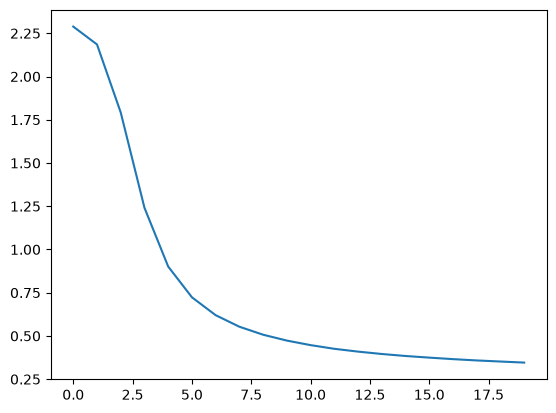

In [37]:
fitted_params, cost_history_initial = optimize(X_train_flatten, y_train)
custom_y_pred = np.argmax(predict(X_test_flatten, fitted_params),axis=1)
print(custom_y_pred)
custom_model_acc = accuracy_score(y_test, custom_y_pred)
print('Custom model accuracy:', custom_model_acc)
plt.plot(cost_history_initial)

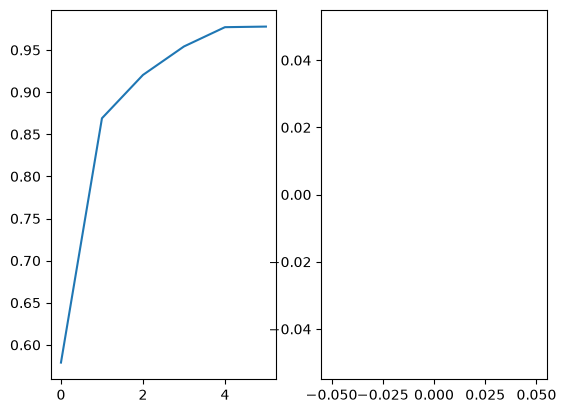

In [ ]:
acc_v_lr = []
acc_v_neurons = []
for i in range(6):
    lr = .001*3**i
    params, cost_history_initial = optimize(X_train_flatten, y_train, learning_rate=lr)
    y_pred = np.argmax(predict(X_test_flatten, params),axis=1)
    acc = accuracy_score(y_test, y_pred)
    acc_v_lr.append(acc)

    neurons = 50*(i+1)
    params, cost_history_initial = optimize(X_train_flatten, y_train, hidden_neurons=neurons)
    y_pred = np.argmax(predict(X_test_flatten, params),axis=1)
    acc = accuracy_score(y_test, y_pred)
    acc_v_neurons.append(acc)
plt.figure()
plt.subplot(121)
plt.plot(acc_v_lr)
plt.subplot(122)
plt.plot(acc_v_neurons)
plt.show()



Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9253 - loss: 0.2590
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9668 - loss: 0.1124
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0765
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9825 - loss: 0.0574
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9866 - loss: 0.0433
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9890 - loss: 0.0350
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9914 - loss: 0.0269
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9935 - loss: 0.0213
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9947 - loss: 0.0171
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9951 - loss: 0.0157
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9966 - loss: 0.0114
Epoch 12/20
1875/1875 ━━━━━━━━

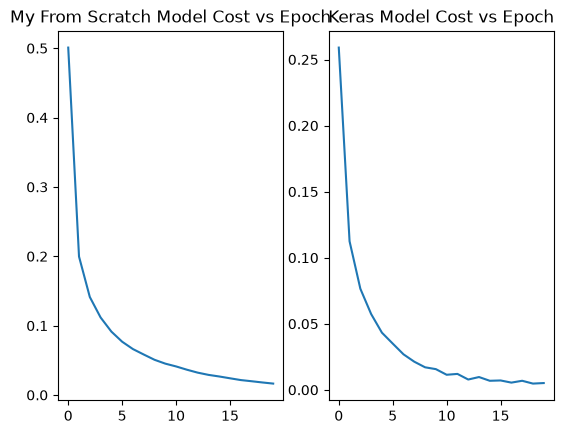

In [ ]:
from tensorflow import keras
keras_model = keras.Sequential([keras.layers.Dense(128, activation="relu"), keras.layers.Dense(10, activation="softmax")])
keras_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
keras_history = keras_model.fit(X_train_flatten, y_train, epochs=20)
plt.figure()
plt.subplot(121)
plt.title("My Model Cost vs Epoch")

best_params, final_cost_history = optimize(X_train_flatten, y_train, learning_rate=.5, hidden_neurons=300)
my_y_pred = np.argmax(predict(X_test_flatten, best_params),axis=1)
my_acc = accuracy_score(y_test, my_y_pred)

plt.plot(final_cost_history)

plt.subplot(122)
plt.title("Keras Model Cost vs Epoch")
plt.plot(keras_history.history['loss'])


keras_y_pred = np.argmax(keras_model.predict(X_test_flatten), axis=1)
keras_acc = accuracy_score(y_test, keras_y_pred)

print("My Accuracy:", my_acc)
print("Keras Accuracy:", keras_acc)

My model was, somewhat suprisingly, able to beat the keras model. While The keras model does concerge significantly faster, my model actually does .6% better. The keras model likely would have done better with parameter tuning. The roughness in the second half of the keras graph implies that it has overfit the training set, meaning regularization parameters likely need to be increased.

In [52]:
np.save("weights.npy", best_params)
np.save("test_image.npy", X_train[0])